# Unbinned template fit WW produkce


Fyzikálně zkoumáme di-muon produkci. Zajímá nás signál z $W^+W^-$ produkce. Zároveň máme background z konkurenčních $WZ$ a $t\bar{t}$. Procesy se liší distribucí pseudorapidit mionů. Měříme proto ji. Reálně nám to je teď ale celkem šumafuk, protože cílem je zjistit jak přesně dokážeme odhadnout frakci signálu WW v datech při daném počtu eventů.

Chceme určovat poměr signálu WW ku pozadí v datech. Chceme to dělat pomocí template fitu z jednotlivých WW, WZ a $t\bar{t}$ distribucí (máme nasimulované nebo změřené odněkud). Fitneme reálná data v praxi takto v pohodě, ale nevíme, jak přesně to je. Cílem tohoto úkolu je proto určit statistickou nejistotu tohohle fitu pomocí Monte Carlo simulace na pseudodatech. Děláme to takto:

**1: Zjistíme frakci**
Otevřeme `.root` soubory a vytáhnem si histogramy. Spočítáme integrál histogramů `Sdata`, `WZbkg` a `ttbarbkg`. Vydělením plochy WW celkovou plochou dostaneme, "skutečnou" frakci událostí WW (~0,094).

**2: Generátor**
Máme histogramy jednotlivých procesů `Sdata`, `WZbkg` a `ttbarbkg`. Ty normalizujeme na PDF. Tj. jdeme z `RooDataHist` na `RooHistPdf`. Vytvoříme složenou PDF `RooAddPdf` sečtením PDF `Sdata`, `WZbkg` a `ttbarbkg` s fixními poměry co jsme spočítali v 1. Tento objekt (z třídy `RooAddPdf`) funguje jako generátor pseudo-dat s právě těmito frakcemi. 

**3: Fit model**
Vytvoříme druhou `RooAddPdf`, tentokrát ale s volnými parametry pro fitování. Místo `Sdata` použijeme ale `Smodel`, abychom prokázali robustnost metody. poměry mezi `Smodel`
 , `WZbkg` a `ttbarbkg` jsou parametry, které fitujeme na pseudodata z 2. 

**4: Monte Carlo**
Uděláme smyčku, která se opakuje 1000krát:
1. Generátor vytvoří 14 000 eventů. (počet nám určuje detektor...máme odhad, kolik eventů se na něm reálně dá očekávat a chceme to simulovat abychom dostali distribuci odhadů frakce WW a tedy i nejistotu měření)
2. Passneme data do fitovacího modelu. Ten napočítá likelihood a minimalizuje ho, dokud nenajde optimální frakce, které nejlépe odpovídají generovaným pseudo-datům.
3. Odhad frakce WW se uloží do histogramu (`histFww`) a generovaná pseudo-data se vymažou z paměti.


**5: Získání nejistoty**
Na konci máme v `histFww` 1000 různých odhadů frakce. Proložíme to Gaussem a získáme tak střední hodnotu a $\sigma$. 

---

## Importy apod.

In [98]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.ticker import AutoMinorLocator

# Spuštění ROOTu v dávkovém režimu (batch mode), aby se zabránilo otevírání externích X11 oken
ROOT.gROOT.SetBatch(True)

%jsroot on
%matplotlib inline
%config InlineBackend.figure_format='retina'

In [74]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1,
    "legend.frameon": True
})

## Data loading
Máme čtyři simulované distribuce:

1.  `data_WWsignal_data.root` (**Sdata**): Považujeme za naši "Skutečnou realitu" (zde je přesně 9,4 % WW).
2.  `data_WWsignal_model.root` (**Smodel**): Realistická simulace, která se liší. Použijeme ji pro fitování, abychom prokázali robustnost metody.
3.  `data_WZbkg.root`: Pozadí WZ.
4.  `data_ttbarbkg.root`: Pozadí $t\bar{t}$.

In [99]:
# Načtení ROOT souborů a extrakce histogramů
fin1 = ROOT.TFile("data/4-RooFit_WW_homework/data_WWsignal_data.root")
h_Sdata = fin1.Get("LepPair_etaprod")

fin11 = ROOT.TFile("data/4-RooFit_WW_homework/data_WWsignal_model.root")
h_Smodel = fin11.Get("LepPair_etaprod")

fin2 = ROOT.TFile("data/4-RooFit_WW_homework/data_ttbarbkg.root")
h_top = fin2.Get("LepPair_etaprod")

fin3 = ROOT.TFile("data/4-RooFit_WW_homework/data_WZbkg.root")
h_wz = fin3.Get("LepPair_etaprod")
h_wz.Scale(1.766 / 1.315)  # Scale faktor....nevím proč


# Integrály histogramů
n_WW_Sdata = h_Sdata.Integral("width")
n_WW_Smodel = h_Smodel.Integral("width")
n_WZ = h_wz.Integral("width")
n_top = h_top.Integral("width")

n_sum_Sdata = n_WW_Sdata + n_WZ + n_top

# Definice etetaeta jako RooRealVar pro fitování
etaeta = ROOT.RooRealVar("etaeta", "etaeta", -6.0, 6.0)

# Výpočet frakcí pro generování pseudo-dat
f_WW_Sdata = ROOT.RooRealVar("f_WW_Sdata", "f_WW_Sdata", n_WW_Sdata / n_sum_Sdata)
f_WZ_Sdata = ROOT.RooRealVar("f_WZ_Sdata", "f_WZ_Sdata", n_WZ / n_sum_Sdata)

print(f_WW_Sdata.getVal(), f_WZ_Sdata.getVal())

0.10177691766006498 0.37587663442596725


## Normalizace na PDF
Standardní histogramy (`TH1D`) obsahují absolutní počty. My chceme kvůli fitování a počítání likelihoodu PDF normalizované na 1. 
Histogramy převedeme na `RooDataHist` a poté na `RooHistPdf`.

Pak smícháme PDF signálu a pozadí pomocí třídy `RooAddPdf`. Když do konstruktoru třídy `RooAddPdf` předáme 3 PDF, vyžaduje pouze 2 proměnné pro frakce. Třetí frakci automaticky dopočítá jako $1 - f_{WW} - f_{WZ}$.

Vytvoříme dvě odlišné `RooAddPdf`:
1. **Generátor:** Používá `Sdata` a výše vypočítané pevné frakce.
2. **Fit model:** Používá `Smodel` a inicializuje volné parametry, které fitujeme.

In [100]:
# Převod TH1D na RooDataHist
rdh_Sdata  = ROOT.RooDataHist("rdh_Sdata", "rdh_Sdata", ROOT.RooArgList(etaeta), h_Sdata)
rdh_Smodel = ROOT.RooDataHist("rdh_Smodel", "rdh_Smodel", ROOT.RooArgList(etaeta), h_Smodel)
rdh_top    = ROOT.RooDataHist("rdh_top", "rdh_top", ROOT.RooArgList(etaeta), h_top)
rdh_wz     = ROOT.RooDataHist("rdh_wz", "rdh_wz", ROOT.RooArgList(etaeta), h_wz)

# Převod RooDataHist na RooHistPdf (Normalizováno na 1)
pdf_Sdata  = ROOT.RooHistPdf("pdf_Sdata", "pdf_Sdata", ROOT.RooArgSet(etaeta), rdh_Sdata)
pdf_Smodel = ROOT.RooHistPdf("pdf_Smodel", "pdf_Smodel", ROOT.RooArgSet(etaeta), rdh_Smodel)
pdf_top    = ROOT.RooHistPdf("pdf_top", "pdf_top", ROOT.RooArgSet(etaeta), rdh_top)
pdf_wz     = ROOT.RooHistPdf("pdf_wz", "pdf_wz", ROOT.RooArgSet(etaeta), rdh_wz)

# 1. Generátor PDF 
pdf_data_gen = ROOT.RooAddPdf("pdf_data_gen", "Data Generator", 
                              ROOT.RooArgList(pdf_Sdata, pdf_wz, pdf_top), 
                              ROOT.RooArgList(f_WW_Sdata, f_WZ_Sdata))

# 2. PDF pro fitování 
f_fit_WW_Smodel = ROOT.RooRealVar("f_fit_WW_Smodel", "Nafitovaná frakce WW", 0.1, 0.0, 1.0)
f_fit_WZ_Smodel = ROOT.RooRealVar("f_fit_WZ_Smodel", "Nafitovaná frakce WZ", 0.1, 0.0, 1.0)

pdf_model_fit = ROOT.RooAddPdf("pdf_model_fit", "Model Fitter", 
                               ROOT.RooArgList(pdf_Smodel, pdf_wz, pdf_top), 
                               ROOT.RooArgList(f_fit_WW_Smodel, f_fit_WZ_Smodel))

## Monte Carlo
Smyčka odhaduje rozptyl fitu. V každé iteraci je vygenerováno 14 000 událostí.

*Poznámka k Pythonu:* Pythonův garbage collector agresivně ničí objekty ROOTu. Na konci každé iterace smyčky musíme explicitně zavolat `.Destructor()` na vygenerovaný dataset. Bez tohoto kroku by PyROOT způsoboval memory leak. Pro 14000 eventů je to cajk, ale snadno to někdo může zkusit s 1 milionem eventů a pak to padne.

In [101]:
# tzv. ROOTe drž hubu!
ROOT.RooMsgService.instance().setGlobalKillBelow(ROOT.RooFit.WARNING)

# Histogramy pro uložení výsledků fitu
histFww = ROOT.TH1F("histFww", "histFww", 50, 0.0, 0.3)
histFwz = ROOT.TH1F("histFwz", "histFwz", 50, 0.3, 0.5)

nRepeats = 1000
nEvents = 14000

print(f"Spouštím smyčku MC pro {nRepeats} iterací...")

for i in range(nRepeats):
    if i % 100 == 0:
        print(f"Zpracovávám událost {i}/{nRepeats}...")
        
    # Generování pseudo-dat
    pseudo_data = pdf_data_gen.generate(ROOT.RooArgSet(etaeta), nEvents)
    
    # Nafitování modelu na pseudo-data
    pdf_model_fit.fitTo(
        pseudo_data, 
        ROOT.RooFit.PrintLevel(-1), 
        ROOT.RooFit.Warnings(False), 
        ROOT.RooFit.PrintEvalErrors(-1)
    )
    
    # Uložení výsledku
    histFww.Fill(f_fit_WW_Smodel.getVal())
    histFwz.Fill(f_fit_WZ_Smodel.getVal())
    
    # Explicitní uvolnění paměti, aby se zabránilo memory leakům
    pseudo_data.IsA().Destructor(pseudo_data)

print("Smyčka dokončena.")

Spouštím smyčku MC pro 1000 iterací...
Zpracovávám událost 0/1000...
Zpracovávám událost 100/1000...
Zpracovávám událost 200/1000...
Zpracovávám událost 300/1000...
Zpracovávám událost 400/1000...
Zpracovávám událost 500/1000...
Zpracovávám událost 600/1000...
Zpracovávám událost 700/1000...
Zpracovávám událost 800/1000...
Zpracovávám událost 900/1000...
Smyčka dokončena.


## Výsledky a vizualizace
Výsledná distribuce našich odhadů by měla tvořit Gaussovu křivku. Fitneme jí a získáme střední hodnotu a $\sigma$.
* ($\mu$) nám ukazuje, zda má naše metoda fitování bias (jestli nadhodnocuje nebo podhodnocuje frakci).
* ($\sigma$) představuje statistickou nejistotu našeho měření.

Osa Y je škálována jako "Události / (šířka binu)". Protože je `histFww` definován s rozsahem osy X od 0,0 do 0,3 a je rozdělen do 50 binů, šířka binu je 0,006.

Root nám dá hezkej interaktivní graf. 

In [102]:
f_fit_var = ROOT.RooRealVar("f_fit_var", "Fitted WW fraction", 0.0, 0.3)
fHist = ROOT.RooDataHist("fHist", "fHist", ROOT.RooArgList(f_fit_var), histFww)

g_mean = ROOT.RooRealVar("g_mean", "Mean", histFww.GetMean(), 0.0, 0.4)
g_sigma = ROOT.RooRealVar("g_sigma", "Sigma", histFww.GetRMS(), 0.0001, 0.5)
g = ROOT.RooGaussian("g", "Gaussian Fit", f_fit_var, g_mean, g_sigma)

# Create Canvas with proper margins
c1 = ROOT.TCanvas("c1", "c1", 800, 600)
c1.SetLeftMargin(0.12)
c1.SetBottomMargin(0.12)
c1.SetTopMargin(0.08)
c1.SetRightMargin(0.05)

fframe = f_fit_var.frame(ROOT.RooFit.Title("Distribution of Fitted WW Signal Fractions"))

# Plot Data and Gaussian Fit
fHist.plotOn(fframe, ROOT.RooFit.MarkerStyle(20), ROOT.RooFit.MarkerSize(0.9), ROOT.RooFit.LineColor(ROOT.kBlack))
fitResult = g.fitTo(fHist, ROOT.RooFit.Save(), ROOT.RooFit.PrintLevel(-1))
g.plotOn(fframe, ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.LineWidth(2))

# Move the parameter box and increase Y-axis headroom
g.paramOn(fframe, ROOT.RooFit.Layout(0.60, 0.95, 0.88))
fframe.SetMaximum(fframe.GetMaximum() * 1.35)
fframe.GetXaxis().SetTitleOffset(1.2)
fframe.GetYaxis().SetTitleOffset(1.4)

fframe.Draw()

# Add custom text
latex = ROOT.TLatex()
latex.SetTextSize(0.04)
latex.SetNDC()
latex.DrawLatex(0.15, 0.82, f"Signal fraction = {g_mean.getVal():.3f} #pm {g_sigma.getVal():.3f}")

c1.SaveAs("Fww.pdf")
c1.Draw()

## Matplotlib

Data snadno vytáhneme z PyROOT do NumPy a můžeme si s nimi hrát v Matplotlibu. 

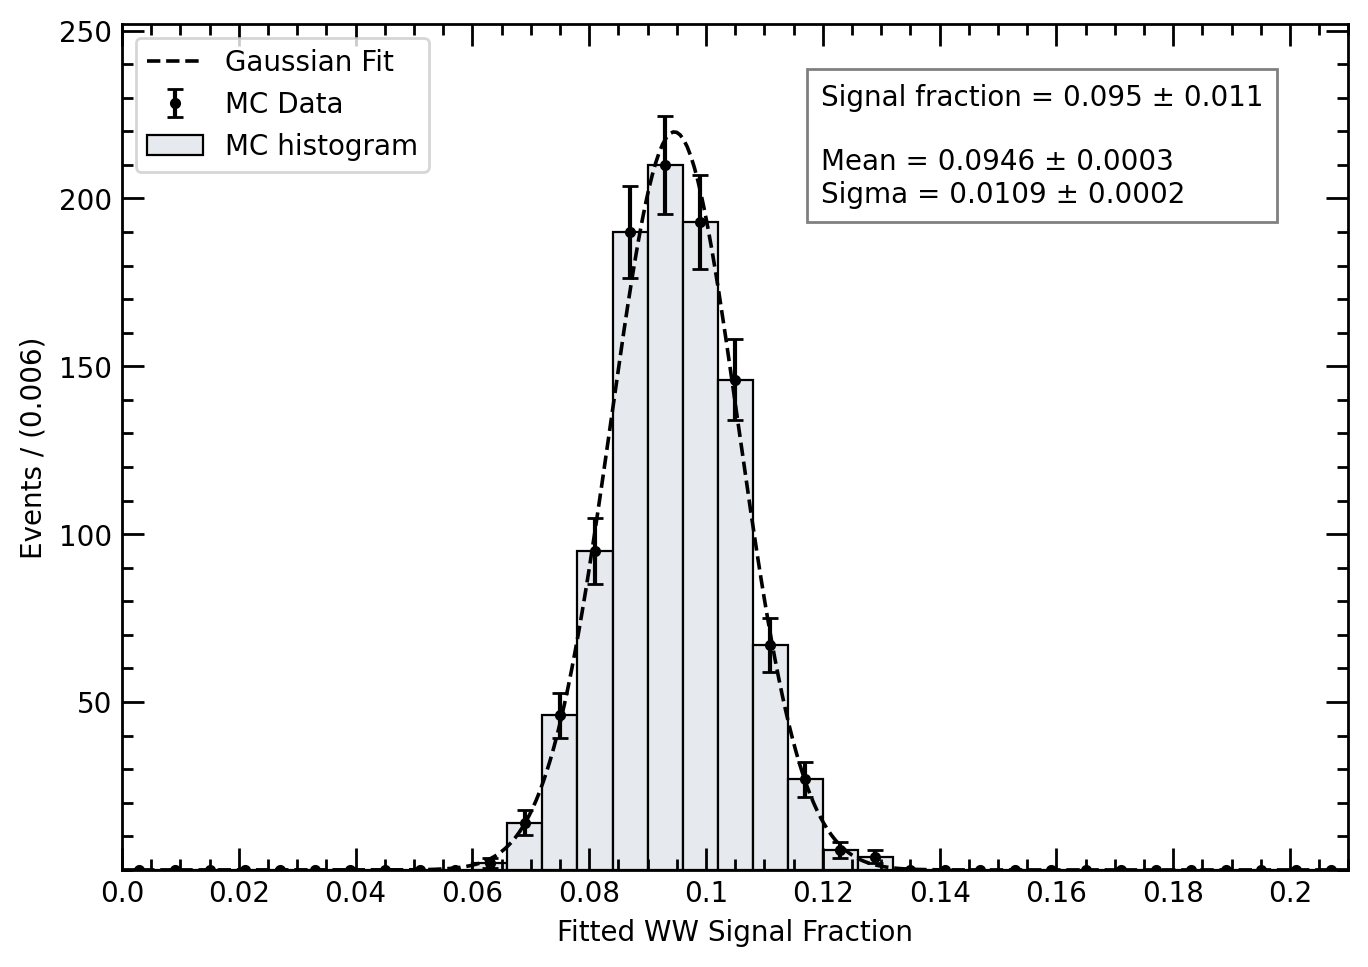

In [97]:
# Extract histogram data directly from the ROOT TH1F object
n_bins = histFww.GetNbinsX()
x_bins = np.array([histFww.GetBinCenter(i) for i in range(1, n_bins + 1)])
y_vals = np.array([histFww.GetBinContent(i) for i in range(1, n_bins + 1)])
y_errs = np.array([histFww.GetBinError(i) for i in range(1, n_bins + 1)])

# Extract the fitted parameters and their errors
mean_val = g_mean.getVal()
sigma_val = g_sigma.getVal()
mean_err = g_mean.getError()
sigma_err = g_sigma.getError()

# Calculate normalization for the fit curve (Total Events * Bin Width)
bin_width = histFww.GetBinWidth(1)
n_total = histFww.Integral()

############
# Plotting #
############

fig, ax = plt.subplots(figsize=(7, 5))

# Plot the MC hist as black points with error bars
ax.errorbar(x_bins, y_vals, yerr=y_errs, fmt='ko', markersize=3, capsize=3, label='MC Data')
#ax.hist(x_bins, bins=n_bins, weights=y_vals, histtype='step', color='black', linewidth=1, label='MC Data Histogram')
ax.bar(x_bins, y_vals, width=bin_width, color='#E6E9ED', edgecolor='black', 
       linewidth=.8, yerr=y_errs, error_kw={'ecolor': 'black', 'elinewidth': 1, 'capsize': 0},
       label='MC histogram', zorder=1)

# Plot the gaussian fit
x_fit = np.linspace(0.0, 0.3, 500)
y_fit = n_total * bin_width * norm.pdf(x_fit, loc=mean_val, scale=sigma_val)
ax.plot(x_fit, y_fit, 'k--', linewidth=1.3, label='Gaussian Fit', zorder=2)


# Formatting and headroom
ax.set_xlabel("Fitted WW Signal Fraction", fontsize=10)
ax.set_ylabel(f"Events / ({bin_width:.3f})", fontsize=10)
ax.set_xlim(0.0, 0.21)
ax.set_ylim(-0.07, max(y_vals) * 1.2) 

# Ticks settings
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(which='both', width=1)
ax.tick_params(which='major', length=8)
ax.tick_params(which='minor', length=4)
ax.set_xticks(np.arange(0, 0.21, 0.02))
ax.set_yticks(np.arange(50, max(y_vals) * 1.2, 50))
ax.set_xticklabels(np.round(ax.get_xticks(), 2), fontsize=10)
ax.set_yticklabels(np.round(ax.get_yticks(), 0).astype(int), fontsize=10)

# Add the parameter and result text box to the top right
textstr = (f"Signal fraction = {mean_val:.3f} ± {sigma_val:.3f}\n\n"
           f"Mean = {mean_val:.4f} ± {mean_err:.4f}\n"
           f"Sigma = {sigma_val:.4f} ± {sigma_err:.4f}")

props = dict(boxstyle='square,pad=0.5', facecolor='white', edgecolor='gray', alpha=1.0)
ax.text(0.57, 0.93, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)

ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()